In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import process_data as pd

In [38]:
QKE = pd.make_data_dictionary("../results/77-QKE_32_3.csv", "../results/51-full_QKE-eps.csv")
QKE.keys()

dict_keys(['time', 'N_bins', 'rho', 'rhobar', 'f', 'Tcm', 'eps', 'w', 'dnde'])

In [39]:
P0, Px, Py, Pz = pd.make_P(QKE['rho'])

In [40]:
V_QKE = pd.V_mat(QKE)

In [41]:
t = QKE['time']
Vy = V_QKE[1,:]
dy = np.diff(Vy)

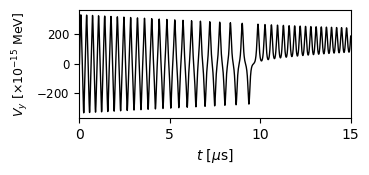

In [42]:
#\delta m^2 = 4 * 10^-18 MeV^2

Vy = pd.V_mat(QKE)[1]
t = QKE['time']
plt.figure(figsize=(3.5, 1.4))

plt.plot(t, Vy*1e15, c='k', lw=1)
plt.xticks([0, 5, 10, 15])
plt.yticks([-200,0,200], [r"$-200$", 0, 200], fontsize=8.5)
plt.xlabel(r"$t~[\mu\text{s}]$", fontsize=10)
plt.ylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=9)
plt.xlim(0, 15)

plt.savefig("Vy.pdf", bbox_inches='tight')

In [43]:
#Finding indices for zero, min, zero, max points (QKE)

tlist = []
Vylist = []

for i in range(len(Vy)-2):
    
    if Vy[i]*Vy[i+1] <= 0:
        tlist.append(i)
        Vylist.append(i)
    if dy[i]*dy[i+1] < 0:
        tlist.append(i)
        Vylist.append(i)

t_index = np.array(tlist)
Vy_index = np.array(Vylist)

print(t[t_index])
print(t_index)
np.where(t[t_index]<9.5)

[ 0.          0.07485486  0.15562814  0.23494818  0.31811177  0.39584864
  0.47478514  0.55945626  0.6420858   0.7218779   0.80412568  0.88893906
  0.96964895  1.0559205   1.13937862  1.22214887  1.30753521  1.3936527
  1.48197134  1.566739    1.65581191  1.741582    1.82656453  1.91597902
  2.00433727  2.09379709  2.18164934  2.27520041  2.36467715  2.45662832
  2.54383116  2.64357843  2.72993114  2.82740893  2.92368029  3.01824449
  3.10521374  3.20595454  3.29914038  3.39747733  3.4940836   3.59583019
  3.69487654  3.79260803  3.89034366  3.99480508  4.0995037   4.19747571
  4.29611414  4.40494853  4.51445484  4.61516187  4.71753974  4.83196686
  4.94267904  5.04719492  5.15595857  5.27078072  5.38242555  5.49504061
  5.6105647   5.72176173  5.83889294  5.95565066  6.07895384  6.19682264
  6.31573398  6.43985758  6.56317913  6.68622149  6.8189929   6.94471664
  7.07548321  7.20677864  7.34341108  7.47330441  7.61625927  7.75569147
  7.89497633  8.04353249  8.19299853  8.3452651   8.

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
        68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
        85, 86, 87]),)

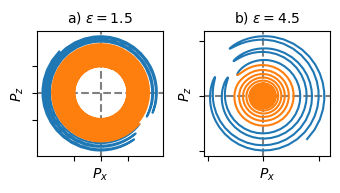

In [56]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(3.5, 2.5))

# Access each plot using indexing
xz1 = axes[0]
xz2 = axes[1]


bloch = [xz1, xz2]

for ax in bloch:
    ax.axhline(0, c='0.50', ls='--')
    ax.axvline(0, c='0.50', ls='--')

label_fontsize = 10

eps_index = 15 

xz1.set_box_aspect(1)
xz1.plot(Px[t_index[79]:t_index[88],15], Pz[t_index[79]:t_index[88],15])
xz1.plot(Px[t_index[88]:,15], Pz[t_index[88]:,15])
xz1.set_ylabel(r"$P_z$", fontsize=label_fontsize)
xz1.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xz1.set_xticks([-0.05, 0, 0.05])
xz1.set_yticks([-0.05, 0, 0.05])
xz1.tick_params(labelbottom=False, labelleft=False) 
#xz1.set_xlim(-0.125,0.125)
#xz1.set_ylim(-0.125,0.135)
xz1.set_title(r"a) $\epsilon = 1.5$", fontsize = label_fontsize)



eps_index = 45

xz2.set_box_aspect(1)
xz2.plot(Px[t_index[79]:t_index[88],eps_index], Pz[t_index[79]:t_index[88],eps_index])
xz2.plot(Px[t_index[88]:,eps_index], Pz[t_index[88]:,eps_index])
xz2.set_ylabel(r"$P_z$", fontsize=label_fontsize)
xz2.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xz2.set_xticks([-0.05, 0, 0.05])
xz2.set_yticks([-0.05, 0, 0.05])
xz2.tick_params(labelbottom=False, labelleft=False) 
#xz2.set_xlim(-0.075,0.075)
#xz2.set_ylim(-0.075,0.075)
xz2.set_title(r"b) $\epsilon = 4.5$", fontsize = label_fontsize)

plt.tight_layout() 
plt.savefig("PxPzDelta.pdf", bbox_inches='tight')

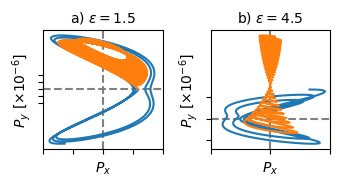

In [58]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(3.5, 2.5))

# Access each plot using indexing
xy1 = axes[0]
xy2 = axes[1]


bloch = [xy1, xy2]

for ax in bloch:
    ax.axhline(0, c='0.50', ls='--')
    ax.axvline(0, c='0.50', ls='--')

label_fontsize = 10

eps_index = 15 

xy1.set_box_aspect(1)
xy1.plot(Px[t_index[79]:t_index[88],15], Py[t_index[79]:t_index[88],15]*1e6)
xy1.plot(Px[t_index[88]:,15], Py[t_index[88]:,15]*1e6)
xy1.set_xticks([-0.12, -0.06, 0, 0.06, 0.12])
xy1.set_yticks([-0.12, -0.06, 0, 0.06, 0.12])
xy1.tick_params(labelbottom=False, labelleft=False) 
xy1.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy1.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
#xy1.set_xlim(0.4,0.6)
#xy1.set_ylim(0.25,0.525)
xy1.set_title(r"a) $\epsilon = 1.5$", fontsize = label_fontsize)

eps_index = 45

xy2.set_box_aspect(1)
xy2.plot(Px[t_index[79]:t_index[88],eps_index], Py[t_index[79]:t_index[88],eps_index]*1e6)
xy2.plot(Px[t_index[88]:,eps_index], Py[t_index[88]:,eps_index]*1e6)
xy2.set_xticks([-0.06, 0, 0.06])
xy2.set_yticks([-0.06, 0, 0.06])
xy2.tick_params(labelbottom=False, labelleft=False) 
xy2.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy2.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
#xy2.set_xlim(-0.075,0.075)
#xy2.set_ylim(0.19,0.285)
xy2.set_title(r"b) $\epsilon = 4.5$", fontsize = label_fontsize)

plt.tight_layout() 
plt.savefig("PxPyDelta.pdf", bbox_inches='tight')

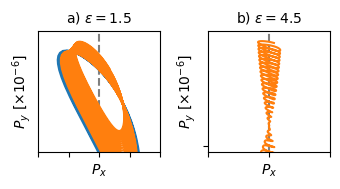

In [72]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(3.5, 2.5))

# Access each plot using indexing
xy1 = axes[0]
xy2 = axes[1]


bloch = [xy1, xy2]

for ax in bloch:
    ax.axhline(0, c='0.50', ls='--')
    ax.axvline(0, c='0.50', ls='--')

label_fontsize = 10

eps_index = 15 

xy1.set_box_aspect(1)
xy1.plot(Px[t_index[94]:t_index[100],15], Py[t_index[94]:t_index[100],15]*1e6)
xy1.plot(Px[t_index[100]:,15], Py[t_index[100]:,15]*1e6)
xy1.set_xticks([-0.12, -0.06, 0, 0.06, 0.12])
xy1.set_yticks([-0.12, -0.06, 0, 0.06, 0.12])
xy1.tick_params(labelbottom=False, labelleft=False) 
xy1.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy1.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
#xy1.set_xlim(0.4,0.6)
xy1.set_ylim(0.2,.45)
xy1.set_title(r"a) $\epsilon = 1.5$", fontsize = label_fontsize)

eps_index = 45

xy2.set_box_aspect(1)
xy2.plot(Px[t_index[94]:t_index[100],eps_index], Py[t_index[94]:t_index[100],eps_index]*1e6)
xy2.plot(Px[t_index[100]:,eps_index], Py[t_index[100]:,eps_index]*1e6)
xy2.set_xticks([-0.06, 0, 0.06])
xy2.set_yticks([-0.06, 0, 0.06])
xy2.tick_params(labelbottom=False, labelleft=False) 
xy2.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy2.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
#xy2.set_xlim(-0.075,0.075)
xy2.set_ylim(0.05,0.25)
xy2.set_title(r"b) $\epsilon = 4.5$", fontsize = label_fontsize)

plt.tight_layout() 
plt.savefig("PxPyDelta.pdf", bbox_inches='tight')